In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim
import optuna
import matplotlib.pyplot as plt

In [2]:
# Set random seed for reproducibility
torch.manual_seed(42)

In [3]:
# Check if GPU is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [4]:
df = pd.read_csv("Learn the Basics PyTorch Officials/data/fmnist_small.csv")

In [5]:
df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,9,0,0,0,0,0,0,0,0,0,...,0,7,0,50,205,196,213,165,0,0
1,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,1,0,0,0,...,142,142,142,21,0,3,0,0,0,0
3,8,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,8,0,0,0,0,0,0,0,0,0,...,213,203,174,151,188,10,0,0,0,0


In [6]:
df.shape

(6000, 785)

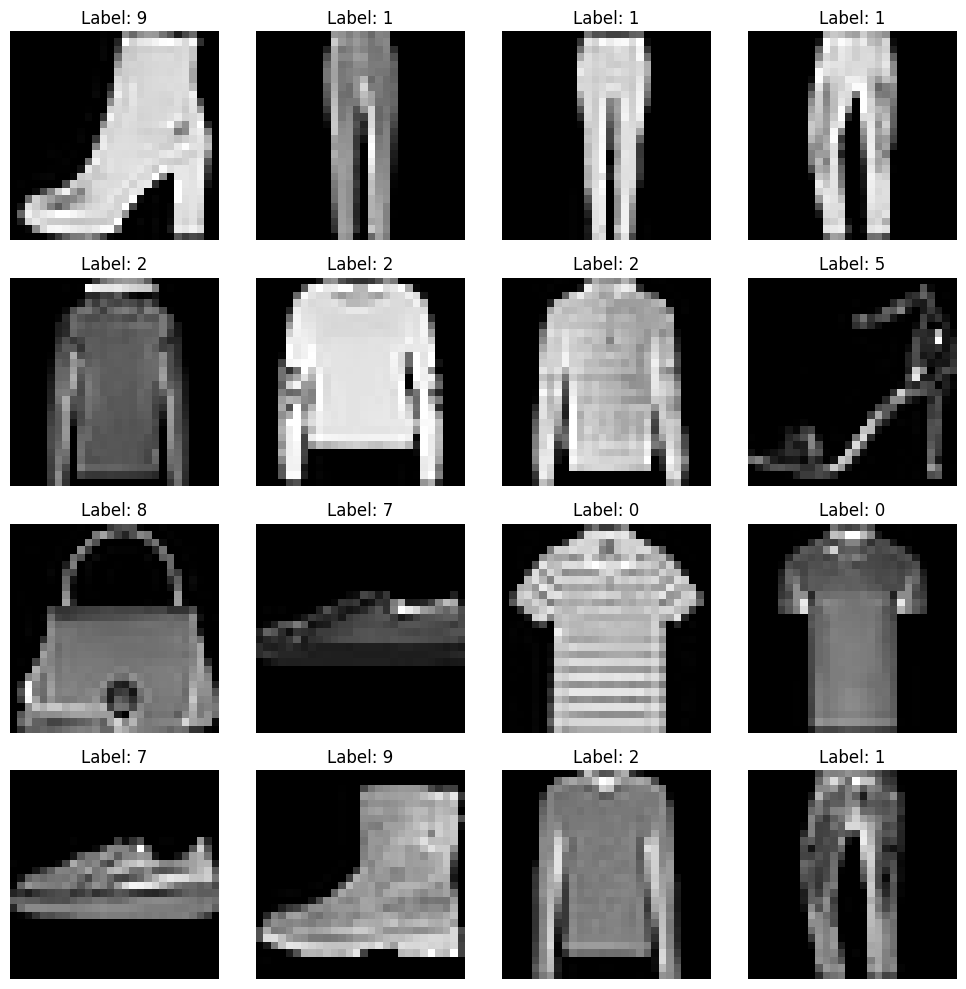

In [7]:
# Display 9 random images from the dataset
# Create a figure with 4x4 subplots
fig, axes = plt.subplots(4, 4, figsize=(10, 10))
# Flatten the axes array for easy iteration
axes = axes.flatten()
# Randomly select 16 indices
random_indices = df.sample(16).index
# Loop through the random indices and plot the images
for i, idx in enumerate(random_indices):
    # Get the image data and label
    image_data = df.iloc[idx, 1:].values.reshape(28, 28)
    label = df.iloc[idx, 0]
    # Plot the image
    axes[i].imshow(image_data, cmap='gray')
    axes[i].set_title(f"Label: {label}")
    axes[i].axis('off')  # Hide the axes
# Hide the remaining axes
for j in range(i + 1, len(axes)):
    axes[j].axis('off')
plt.tight_layout()
plt.show()

In [8]:
# Split the dataset into features and labels
X = df.iloc[:, 1:].values
y = df.iloc[:, 0].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [9]:
# Normalize the data
X_train = X_train / 255.0
X_test = X_test / 255.0

In [10]:
# Create a custom dataset class
class FashionMNISTDataset(Dataset):
    def __init__(self, features, labels):
        self.features = torch.tensor(features, dtype=torch.float32)
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.features[idx], self.labels[idx]

In [11]:
# Create DataLoader for training and testing
train_dataset = FashionMNISTDataset(X_train, y_train)
test_dataset = FashionMNISTDataset(X_test, y_test)

In [12]:
class FashionMNISTModel(nn.Module):
    def __init__(self, input_size, 
                        output_size,
                        num_hidden_layers,
                        neurons_per_layer,
                        dropout_rate):
        super().__init__()

        layers = []

        for i in range(num_hidden_layers):
            layers.append(nn.Linear(input_size, neurons_per_layer))
            layers.append(nn.BatchNorm1d(neurons_per_layer))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout_rate))
            input_size = neurons_per_layer
        layers.append(nn.Linear(neurons_per_layer, output_size))

        self.model = nn.Sequential(*layers)

    def forward(self, x):
        return self.model(x)

In [15]:
def objective(trial):
    # Hyperparameters
    num_hidden_layers = trial.suggest_int("num_hidden_layers", 1, 5)
    neurons_per_layer = trial.suggest_int("neurons_per_layer", 8, 128, step=8)
    epochs = trial.suggest_int("epochs", 10, 50, step=10)
    learning_rate = trial.suggest_float("learning_rate", 1e-5, 1e-1, log=True)  # Fixed: suggest_loguniform -> suggest_float with log=True
    dropout_rate = trial.suggest_float("dropout_rate", 0.1, 0.5)  # Fixed: suggest_uniform doesn't accept step
    batch_size = trial.suggest_categorical("batch_size", [16, 32, 64, 128])  # Fixed: suggest_int -> suggest_categorical for discrete choices
    optimizer_name = trial.suggest_categorical("optimizer", ["Adam", "SGD", "RMSprop"])
    weight_decay = trial.suggest_float("weight_decay", 1e-5, 1e-2, log=True)  # Fixed: suggest_loguniform -> suggest_float with log=True

    # Create DataLoader for training and testing
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    # Model init
    input_size = 784
    output_size = 10

    model = FashionMNISTModel(input_size, output_size, num_hidden_layers, neurons_per_layer, dropout_rate).to(device)

    # Optimizer
    criterion = nn.CrossEntropyLoss()
    if optimizer_name == "Adam":
        optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
    elif optimizer_name == "SGD":
        optimizer = optim.SGD(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
    elif optimizer_name == "RMSprop":
        optimizer = optim.RMSprop(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
    else:
        raise ValueError(f"Unsupported optimizer: {optimizer_name}")

    # Training loop
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        print(f"Epoch [{epoch + 1}/{epochs}], Loss: {running_loss / len(train_loader):.4f}")
    
    # Evaluation
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    accuracy = correct / total
    print(f"Accuracy: {accuracy:.4f}")
    return accuracy

In [ ]:
# Create a study object and optimize the objective function
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=10)

In [17]:
print("Best trial:")
best_trial = study.best_trial
print(f"  Value: {best_trial.value}")
print("  Params:")
for key, value in best_trial.params.items():
    print(f"    {key}: {value}")

Best trial:
  Value: 0.83
  Params:
    num_hidden_layers: 2
    neurons_per_layer: 72
    epochs: 30
    learning_rate: 3.262542208419429e-05
    dropout_rate: 0.18688050673070955
    batch_size: 32
    optimizer: RMSprop
    weight_decay: 0.005272461785872104
